# L01 — Intro to MRI: Hands-on Notebook

**Companion to** `L01_summary.md`

This notebook brings Lecture 1 to life with code. After today you will have:

1. ✅ A working Python + NumPy + Matplotlib environment
2. ✅ A **Larmor frequency calculator** for any nucleus at any field strength
3. ✅ A visualization of the **B₀ field** with a sample inside it
4. ✅ An animation of a **spinning magnetization vector** (the protagonist of the whole course)
5. ✅ Plots of **T₁ recovery** and **T₂ decay** for liver, fat, and CSF
6. ✅ A toy **T₂-weighted contrast** demo showing why long TE makes fluid bright

**Run cells top to bottom.** Read the comments — they explain *why*, not just *what*.

## 0. Setup

We only need the basics today: NumPy for math, Matplotlib for plots.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib import animation
from IPython.display import HTML

# A few defaults so the figures look nice
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('Environment ready')
print(f'NumPy version: {np.__version__}')

Environment ready
NumPy version: 2.4.4


## 1. The Larmor frequency calculator

Recall the magic equation:

$$\nu_0 = \frac{\gamma}{2\pi} B_0$$

where $\gamma$ is the **gyromagnetic ratio** (a fundamental constant of each nucleus) and $B_0$ is the field strength.

Different nuclei have different $\gamma$'s, which is why MRI almost always images **protons (¹H)** — they have one of the largest gyromagnetic ratios *and* are the most abundant nucleus in the human body (water, fat).

Below we encode a small table of nuclei and build a reusable function.

In [3]:
# Gyromagnetic ratios in rad / s / T (sign matters but we'll use magnitudes)
# Values from standard NMR tables.
GYROMAGNETIC_RATIOS = {
    '1H  (proton)':         2.6752218744e8,   # the workhorse of MRI
    '13C (carbon-13)':      6.728284e7,
    '19F (fluorine-19)':    2.518148e8,       # very close to proton
    '23Na (sodium-23)':     7.0808493e7,      # used in functional imaging
    '31P (phosphorus-31)':  1.0839e8,         # used in MR spectroscopy
    '129Xe (xenon-129)':    -7.452103e7,      # used in lung MRI (hyperpolarized)
}

def larmor_frequency(B0_tesla, gamma_rad_per_s_per_T=2.6752218744e8):
    """Return Larmor frequency in Hz for a given field strength and gyromagnetic ratio."""
    return gamma_rad_per_s_per_T * B0_tesla / (2 * np.pi)

# Quick test: what's the proton Larmor frequency at clinical field strengths?
print(f"{'Field (T)':>10} {'Larmor freq (MHz)':>22}")
print('-' * 35)
for B0 in [0.5, 1.5, 3.0, 7.0, 11.7]:
    f = larmor_frequency(B0) / 1e6
    print(f'{B0:>10.2f} {f:>22.3f}')

 Field (T)      Larmor freq (MHz)
-----------------------------------
      0.50                 21.289
      1.50                 63.866
      3.00                127.732
      7.00                298.042
     11.70                498.156


**Sanity check:** The lecture states ~63 MHz at 1.5T and ~126 MHz at 3T. Our calculator agrees. 

Now let's see how *different nuclei* compare at a fixed field strength.

In [4]:
B0 = 3.0  # Tesla — a typical clinical field

print(f'Larmor frequencies at {B0} T:\n')
for name, gamma in GYROMAGNETIC_RATIOS.items():
    f = larmor_frequency(B0, abs(gamma)) / 1e6
    bar = '█' * int(f / 5)  # crude bar chart
    print(f'  {name:<22}  {f:>7.2f} MHz  {bar}')

print('\nProton dominance is no accident — it sits near the top, AND')
print('the human body is ~60% water, so we have ~10²³ protons per cm³.')

Larmor frequencies at 3.0 T:

  1H  (proton)             127.73 MHz  █████████████████████████
  13C (carbon-13)           32.13 MHz  ██████
  19F (fluorine-19)        120.23 MHz  ████████████████████████
  23Na (sodium-23)          33.81 MHz  ██████
  31P (phosphorus-31)       51.75 MHz  ██████████
  129Xe (xenon-129)         35.58 MHz  ███████

Proton dominance is no accident — it sits near the top, AND
the human body is ~60% water, so we have ~10²³ protons per cm³.


###  Try it yourself
- What's the Larmor frequency of a proton at the field of an MRI used in mice (e.g., 9.4T)?
- Why might using ²³Na or ³¹P be useful clinically, despite the much lower frequency?
- What field strength would push proton Larmor frequency above 1 GHz?

## 2. Visualizing the B₀ field

The lecture's Figure 2.1.1.i shows a sample sitting in a uniform field $\mathbf{B}_0 = B_0 \mathbf{e}_z$. Let's draw our own version with matplotlib's quiver plot.

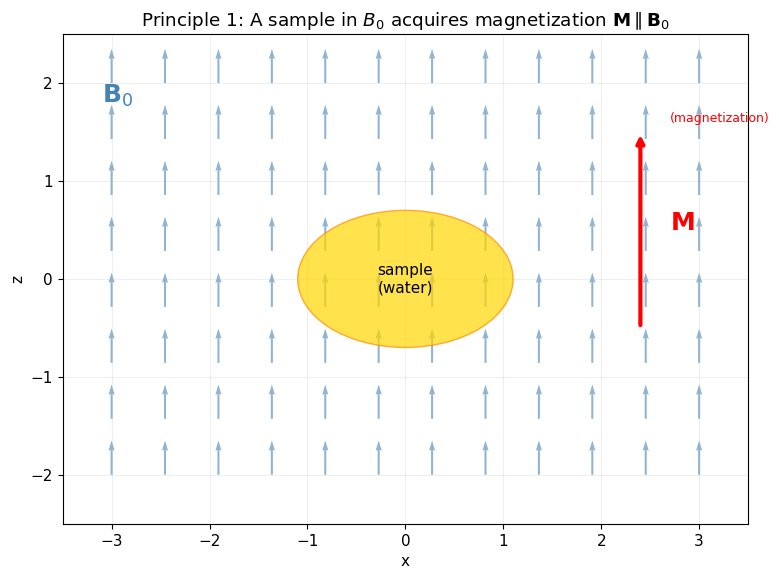

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

# Grid of arrow positions
x = np.linspace(-3, 3, 12)
y = np.linspace(-2, 2, 8)
X, Y = np.meshgrid(x, y)

# B0 is uniform and points in +z (which is 'up' in our 2D drawing)
U = np.zeros_like(X)        # x-component
V = np.ones_like(Y)         # y-component (representing z in our 2D view)

ax.quiver(X, Y, U, V, color='steelblue', alpha=0.6, scale=20, width=0.003)

# Add a 'sample' (a brain-shaped blob of water)
from matplotlib.patches import Ellipse
sample = Ellipse(xy=(0, 0), width=2.2, height=1.4,
                 facecolor='gold', edgecolor='darkorange', alpha=0.7, zorder=3)
ax.add_patch(sample)
ax.text(0, 0, 'sample\n(water)', ha='center', va='center', fontsize=11, zorder=4)

# Resulting magnetization M (pointing up because M ∥ B0)
ax.annotate('', xy=(2.4, 1.5), xytext=(2.4, -0.5),
            arrowprops=dict(arrowstyle='-|>', color='red', lw=3))
ax.text(2.7, 0.5, '$\\mathbf{M}$', color='red', fontsize=18)
ax.text(2.7, 1.6, '(magnetization)', color='red', fontsize=9)

ax.text(-3.1, 1.8, '$\\mathbf{B}_0$', color='steelblue', fontsize=18)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_title('Principle 1: A sample in $B_0$ acquires magnetization $\\mathbf{M} \\parallel \\mathbf{B}_0$')
ax.set_xlabel('x'); ax.set_ylabel('z')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**What you're seeing:** The blue arrows are the static $\mathbf{B}_0$ field — uniform, always pointing along $+z$. Inside the sample, all the proton magnetic moments collectively produce a macroscopic magnetization $\mathbf{M}$ (red arrow), aligned with $\mathbf{B}_0$.

This is the resting state. Nothing is happening yet — no signal. To get a signal we need to *tip* $\mathbf{M}$ away from $\mathbf{B}_0$.

## 3. The spinning magnetization (a teaser of Lecture 5)

The lecture hints at the central question: *how does a magnetization parallel to* $\mathbf{B}_0$ *produce a time-varying field that can induce a current?*

**Answer (which we'll derive properly later):** When tipped away from $\mathbf{B}_0$, $\mathbf{M}$ doesn't just sit there — it **precesses** around $\mathbf{B}_0$ at the Larmor frequency, like a spinning top wobbling in gravity.

Let's animate it.

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3D projection

# We'll animate M precessing around the z-axis (B0 direction)
# at a chosen Larmor frequency. We slow it down massively so we can see it —
# at 3T, ν0 ≈ 126 MHz which is way too fast to visualize directly.

tip_angle = np.deg2rad(60)   # M is tipped 60° from z
n_frames = 60
phi = np.linspace(0, 2 * np.pi, n_frames)  # one full revolution

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

def draw_frame(i):
    ax.clear()
    
    # B0 field arrow along +z
    ax.quiver(0, 0, 0, 0, 0, 1.4, color='steelblue', lw=3, arrow_length_ratio=0.1)
    ax.text(0.05, 0.05, 1.5, '$\\mathbf{B}_0$', fontsize=14, color='steelblue')
    
    # Magnetization vector M, tipped by tip_angle and rotating around z
    Mx = np.sin(tip_angle) * np.cos(phi[i])
    My = np.sin(tip_angle) * np.sin(phi[i])
    Mz = np.cos(tip_angle)
    ax.quiver(0, 0, 0, Mx, My, Mz, color='red', lw=3, arrow_length_ratio=0.12)
    ax.text(Mx*1.1, My*1.1, Mz*1.1, '$\\mathbf{M}$', fontsize=14, color='red')
    
    # Draw the precession circle (the path the tip of M traces out)
    theta = np.linspace(0, 2 * np.pi, 100)
    cx = np.sin(tip_angle) * np.cos(theta)
    cy = np.sin(tip_angle) * np.sin(theta)
    cz = np.full_like(theta, np.cos(tip_angle))
    ax.plot(cx, cy, cz, color='red', alpha=0.25, ls='--')
    
    # Cosmetic: axes + bounds
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1.6)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(f'Larmor precession of $\\mathbf{{M}}$ around $\\mathbf{{B}}_0$\n'
                 f'(frame {i+1}/{n_frames})')

anim = animation.FuncAnimation(fig, draw_frame, frames=n_frames, interval=80)
plt.close()  # don't show the static final frame
HTML(anim.to_jshtml())

**What you're seeing:** $\mathbf{M}$ traces out a cone around $\mathbf{B}_0$. The tip moves in a circle in the $xy$-plane.

**Why this matters for signal detection:** A receive coil placed near the sample sees the *transverse* component of $\mathbf{M}$ (the $xy$ part) sweep past at the Larmor frequency. By Faraday's law, this oscillating field induces a voltage in the coil — that's our signal.

**At rest** (M parallel to B₀), the transverse component is zero → no oscillation → no signal. **After RF excitation** (M tipped), there's a transverse component that precesses → oscillating B₁⁻ → induced current → signal. ✨

*(All of this is properly derived in L05–L07 from the Bloch equations. For now: enjoy the wobble.)*

## 4. Relaxation curves: T₂ decay and T₁ recovery

From Principle 3:

- **T₂ decay:** Transverse signal dies as $\exp(-t/T_2)$
- **T₁ recovery:** Longitudinal magnetization recovers as $M_0(1 - \exp(-t/T_1))$ (assuming we started from zero)

Different tissues have different $T_1$ and $T_2$. Let's plot the values from the lecture.

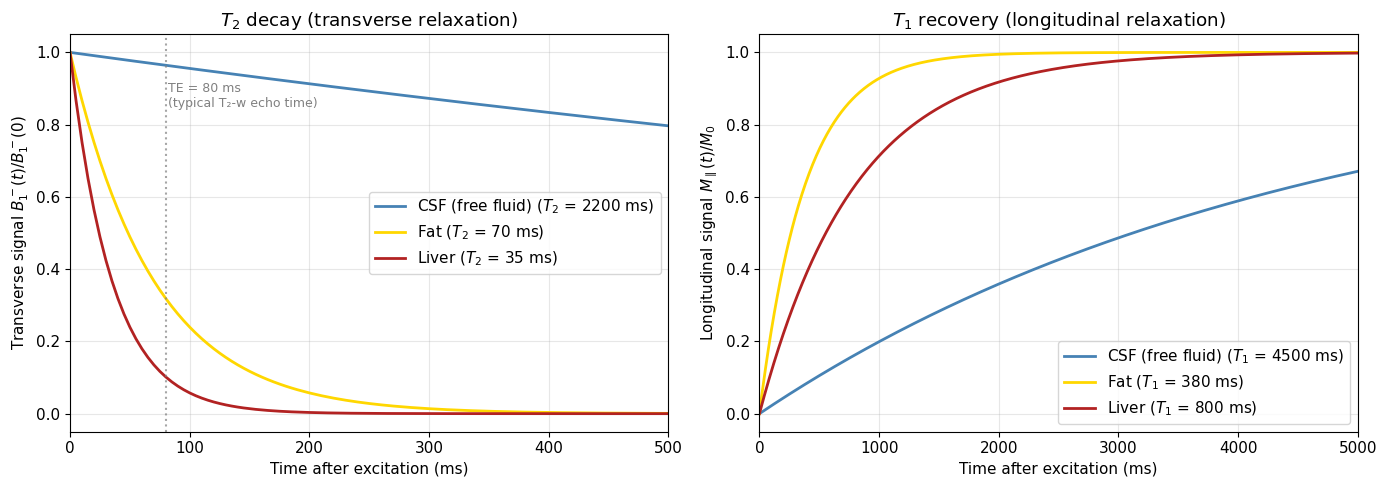

In [7]:
# Tissue relaxation times (ms) at ~1.5T from the lecture
tissues = {
    'CSF (free fluid)': dict(T1=4500, T2=2200, color='steelblue'),
    'Fat':              dict(T1=380,  T2=70,   color='gold'),
    'Liver':            dict(T1=800,  T2=35,   color='firebrick'),
}

t = np.linspace(0, 5000, 1000)  # milliseconds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- T2 decay ---
for name, props in tissues.items():
    signal = np.exp(-t / props['T2'])
    ax1.plot(t, signal, label=f"{name} ($T_2$ = {props['T2']} ms)",
             color=props['color'], lw=2)
ax1.set_xlim(0, 500)
ax1.set_xlabel('Time after excitation (ms)')
ax1.set_ylabel('Transverse signal $B_1^-(t) / B_1^-(0)$')
ax1.set_title('$T_2$ decay (transverse relaxation)')
ax1.legend()
ax1.axvline(80, color='gray', ls=':', alpha=0.7)
ax1.text(82, 0.85, 'TE = 80 ms\n(typical T₂-w echo time)', fontsize=9, color='gray')

# --- T1 recovery ---
for name, props in tissues.items():
    Mz = 1 - np.exp(-t / props['T1'])
    ax2.plot(t, Mz, label=f"{name} ($T_1$ = {props['T1']} ms)",
             color=props['color'], lw=2)
ax2.set_xlim(0, 5000)
ax2.set_xlabel('Time after excitation (ms)')
ax2.set_ylabel('Longitudinal signal $M_\\parallel(t) / M_0$')
ax2.set_title('$T_1$ recovery (longitudinal relaxation)')
ax2.legend()

plt.tight_layout()
plt.show()

**Read the T₂ plot left-to-right:** All tissues start at signal = 1. By 80ms, liver has decayed to ~10% but CSF is barely below 1. **That difference is the contrast** in a T₂-weighted image.

**Read the T₁ plot:** Fat recovers fastest (small $T_1$), CSF slowest. This is the basis of T₁-weighted contrast (covered in Module 3).

## 5. Toy T₂-weighted contrast: "why is fluid bright?"

Let's build a tiny synthetic phantom — a 2D image with three regions of different $T_2$ — and see how the *visible contrast* changes as we vary the echo time TE.

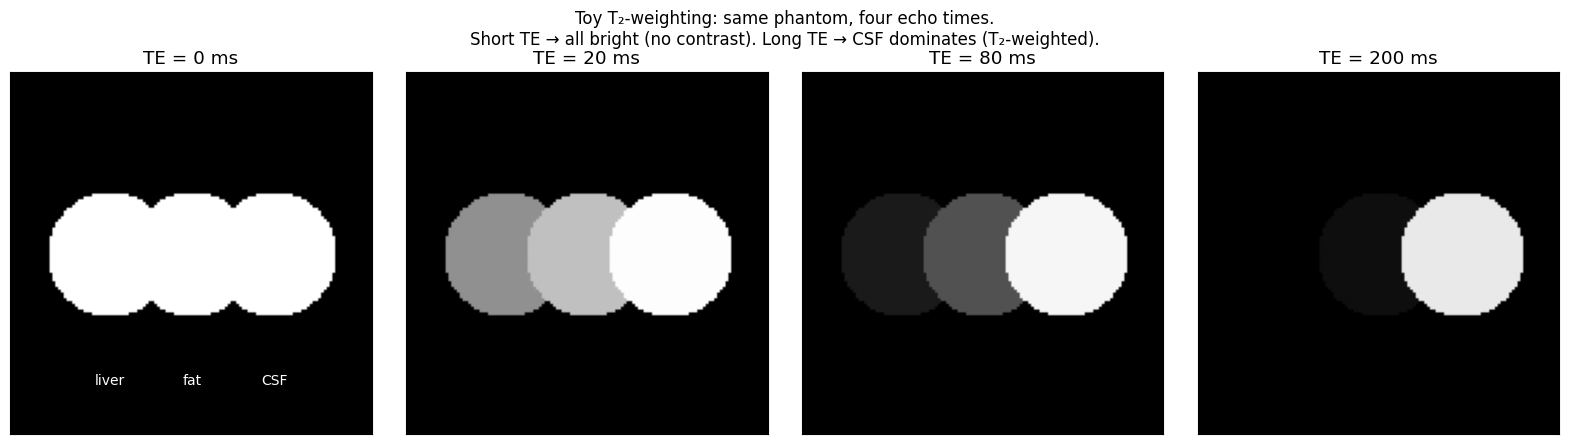

In [8]:
# Build a simple phantom: 128x128 image with 3 circular regions
size = 128
y, x = np.ogrid[:size, :size]

# Three circles representing different tissues
T2_map = np.zeros((size, size))
rho_map = np.zeros((size, size))  # proton density

# Circle 1: liver-like (left)
mask1 = (x - 35)**2 + (y - 64)**2 < 22**2
T2_map[mask1] = 35   # ms
rho_map[mask1] = 1.0

# Circle 2: fat-like (center)
mask2 = (x - 64)**2 + (y - 64)**2 < 22**2
T2_map[mask2] = 70
rho_map[mask2] = 1.0

# Circle 3: CSF-like (right)
mask3 = (x - 93)**2 + (y - 64)**2 < 22**2
T2_map[mask3] = 2200
rho_map[mask3] = 1.0

# Plot images at different echo times
TEs = [0, 20, 80, 200]   # ms

fig, axes = plt.subplots(1, len(TEs), figsize=(16, 4.5))
for ax, TE in zip(axes, TEs):
    # Signal at echo time TE for each pixel
    with np.errstate(divide='ignore', invalid='ignore'):
        signal = np.where(T2_map > 0,
                          rho_map * np.exp(-TE / np.where(T2_map > 0, T2_map, 1)),
                          0)
    ax.imshow(signal, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'TE = {TE} ms')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].text(35, 110, 'liver',  ha='center', color='white', fontsize=10)
axes[0].text(64, 110, 'fat',    ha='center', color='white', fontsize=10)
axes[0].text(93, 110, 'CSF',    ha='center', color='white', fontsize=10)

fig.suptitle('Toy T₂-weighting: same phantom, four echo times.\n'
             'Short TE → all bright (no contrast). Long TE → CSF dominates (T₂-weighted).',
             fontsize=12)
plt.tight_layout()
plt.show()

**This is the punchline of the whole lecture in one figure.**

- At **TE = 0**: all three tissues have the same brightness (proton density only). No diagnostic value beyond density.
- At **TE = 20 ms**: tiny contrast emerging — liver darkening slightly.
- At **TE = 80 ms**: clinically useful T₂-w. Liver is gray, fat is bright, CSF is brightest.
- At **TE = 200 ms**: heavy T₂-weighting. Liver is gone. Only fluids glow.

This is *exactly* why CSF appears bright in real T₂-weighted brain images, and why a clinician chooses TE based on the diagnostic question.

## 6. Position-dependent Larmor frequency (preview of image encoding)

Final demo for today: visualize how a **gradient field** $G$ in the $x$-direction makes the Larmor frequency depend on position:

$$\nu(x) = \frac{\gamma}{2\pi}(B_0 + G\cdot x)$$

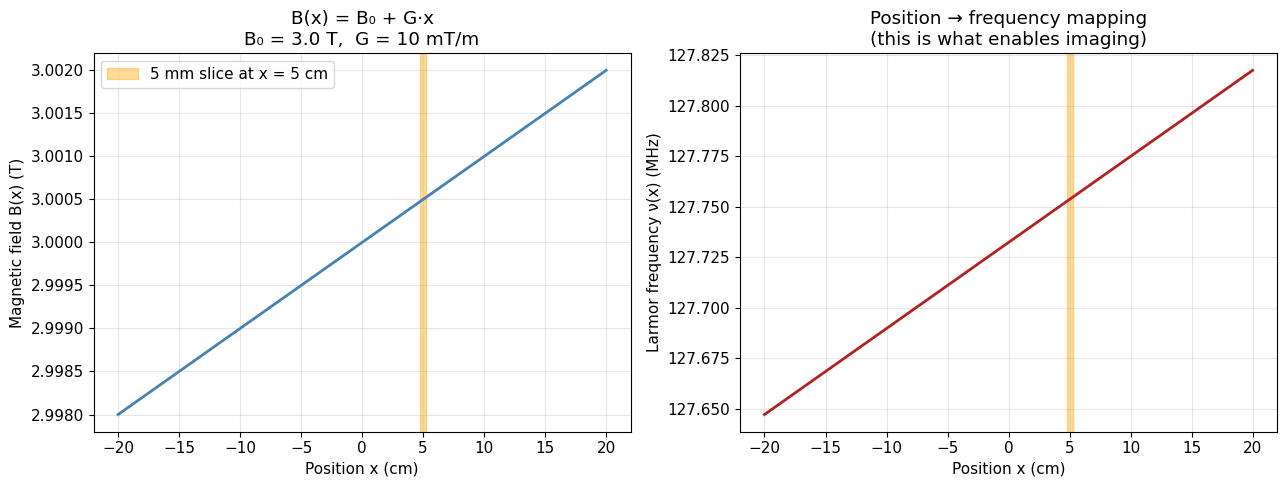


To excite a 5.0 mm slice with G = 10 mT/m:
  required RF bandwidth ≈ 2129 Hz = 2.13 kHz


In [9]:
B0 = 3.0                          # tesla
G  = 10e-3                        # T/m (10 mT/m, a typical gradient strength)
gamma = 2.6752218744e8           # rad/s/T

x = np.linspace(-0.2, 0.2, 200)   # ± 20 cm field of view
B_total = B0 + G * x
nu = gamma * B_total / (2 * np.pi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(x * 100, B_total, lw=2, color='steelblue')
ax1.set_xlabel('Position x (cm)')
ax1.set_ylabel('Magnetic field B(x) (T)')
ax1.set_title(f'B(x) = B₀ + G·x\nB₀ = {B0} T,  G = {G*1e3:.0f} mT/m')

ax2.plot(x * 100, nu / 1e6, lw=2, color='firebrick')
ax2.set_xlabel('Position x (cm)')
ax2.set_ylabel('Larmor frequency ν(x) (MHz)')
ax2.set_title('Position → frequency mapping\n(this is what enables imaging)')

# Highlight a 'slice' that would be excited by a narrow-band RF pulse
slice_center = 0.05  # 5 cm
slice_thickness = 0.005  # 5 mm
ax1.axvspan((slice_center - slice_thickness/2)*100,
            (slice_center + slice_thickness/2)*100,
            color='orange', alpha=0.4, label='5 mm slice at x = 5 cm')
ax2.axvspan((slice_center - slice_thickness/2)*100,
            (slice_center + slice_thickness/2)*100,
            color='orange', alpha=0.4)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

# What's the bandwidth of the RF pulse needed to excite that 5mm slice?
df = gamma * G * slice_thickness / (2 * np.pi)
print(f'\nTo excite a {slice_thickness*1000:.1f} mm slice with G = {G*1e3:.0f} mT/m:')
print(f'  required RF bandwidth ≈ {df:.0f} Hz = {df/1000:.2f} kHz')

**That orange band is your slice.** A real RF pulse with the calculated bandwidth (~2 kHz here) would excite *only* the protons inside that 5 mm slab and leave the rest of the body untouched. We'll design these pulses properly in L11.

---

##  Summary of what you built today

1. A **Larmor frequency calculator** that confirms textbook values across nuclei and field strengths
2. A diagram of a **sample magnetized in $\mathbf{B}_0$** — the resting state of every MRI experiment
3. A **3D animation of precession** — the central motion of MRI
4. **T₁/T₂ relaxation curves** for liver, fat, and CSF — the source of contrast
5. A **toy T₂-weighted image series** showing why fluids look bright at long TE
6. A **gradient + slice-selection preview** — the basic trick of image encoding

Every concept here is either a one-line equation or a few lines of Python. Internalize the *intuition*; the equations come back later.

##  Stretch goals (optional — for the curious)

If you have extra time today, try:

1. **Modify the precession animation** to also show what happens if $\mathbf{M}$ is *not* tipped (i.e., still parallel to $\mathbf{B}_0$). What does the receive coil 'see'?
2. **Add a 4th tissue** to the T₂ contrast demo — say, white matter ($T_2 \approx 80$ ms, proton density 0.7) — and see if you can find a TE that makes it pop out from the others.
3. **Plot the SNR scaling with $B_0$.** If signal $\propto B_0$ and noise $\propto B_0^{1/2}$ (a real-world approximation), how much SNR does going from 1.5T to 7T buy you?
